In [1]:
from typing import *

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy, mode

from sklearn.datasets import make_classification
from sklearn.preprocessing import OrdinalEncoder, PolynomialFeatures
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, validation_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB

In [2]:
dataset = pd.read_csv('student_exam_data.csv')
dataset.head()

,Контрольная 1,Контрольная 2,Контрольная 3,Сон накануне,Настроение,Энергетиков накануне,Посещаемость занятий,Время подготовки,Сдал
0,4,4,9,Нет,Хорошее,4+,Низкая,За неделю,Нет
1,9,9,6,Да,Плохое,1,Средняя,Последний час,Да
2,8,6,9,Да,Хорошее,2-3,Средняя,Последний час,Да
3,8,4,9,Да,Хорошее,1,Высокая,Последняя ночь,Да
4,9,10,4,Нет,Нормальное,1,Низкая,Последний час,Да


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Контрольная 1         300 non-null    int64 
 1   Контрольная 2         300 non-null    int64 
 2   Контрольная 3         300 non-null    int64 
 3   Сон накануне          300 non-null    object
 4   Настроение            300 non-null    object
 5   Энергетиков накануне  300 non-null    object
 6   Посещаемость занятий  300 non-null    object
 7   Время подготовки      300 non-null    object
 8   Сдал                  300 non-null    object
dtypes: int64(3), object(6)
memory usage: 21.2+ KB


In [4]:
dataset.describe()

,Контрольная 1,Контрольная 2,Контрольная 3
count,300.000000,300.000000,300.000000
mean,7.130000,6.936667,6.940000
std,2.003283,2.009839,2.028987
min,4.000000,4.000000,4.000000
25%,5.000000,5.000000,5.000000
50%,7.000000,7.000000,7.000000
75%,9.000000,9.000000,9.000000
max,10.000000,10.000000,10.000000


In [5]:
dataset['Время подготовки'].unique()

array(['За неделю', 'Последний час', 'Последняя ночь',
       'За несколько дней'], dtype=object)

In [6]:
category_feature_names = ["Сон накануне","Настроение","Энергетиков накануне",
                          "Посещаемость занятий","Время подготовки"] 

In [7]:
feature_replace_rules = {
    "Сон накануне":{"Да":1, "Нет":0},
    "Настроение":{"Хорошее":2, "Нормальное":1, "Плохое":0},
    "Энергетиков накануне":{"4+":4, "2-3":3, "1":1, "0":0},
    "Посещаемость занятий":{"Высокая":2, "Средняя":1, "Низкая":0},
    "Время подготовки":{"За неделю":3, "За несколько дней":2,
                        "Последняя ночь":1, "Последний час":0},
    "Сдал":{"Да":1, "Нет":0}
}

In [8]:
dataset.replace(feature_replace_rules, inplace=True) 
dataset.head()

C:\Users\trxxnk\AppData\Local\Temp\ipykernel_11304\3805742375.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.replace(feature_replace_rules, inplace=True)


,Контрольная 1,Контрольная 2,Контрольная 3,Сон накануне,Настроение,Энергетиков накануне,Посещаемость занятий,Время подготовки,Сдал
0,4,4,9,0,2,4,0,3,0
1,9,9,6,1,0,1,1,0,1
2,8,6,9,1,2,3,1,0,1
3,8,4,9,1,2,1,2,1,1
4,9,10,4,0,1,1,0,0,1


In [9]:
# dataset['Сдал'].replace({"Да":1, "Нет":0}, inplace=True)

# for feature_name in category_feature_names:
#     encoder = OrdinalEncoder()
#     values = dataset[feature_name].values.reshape((-1,1))
#     new_column = encoder.fit_transform(values)
#     dataset[feature_name] = new_column
#     dataset[feature_name] = dataset[feature_name].astype(dtype='int64')

# dataset.head()

C:\Users\trxxnk\AppData\Local\Temp\ipykernel_11304\2752230614.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Средняя отметка'] = df.drop(['Сдал'], axis=1).mean(axis=1).round()


<Axes: xlabel='Средняя отметка', ylabel='count'>

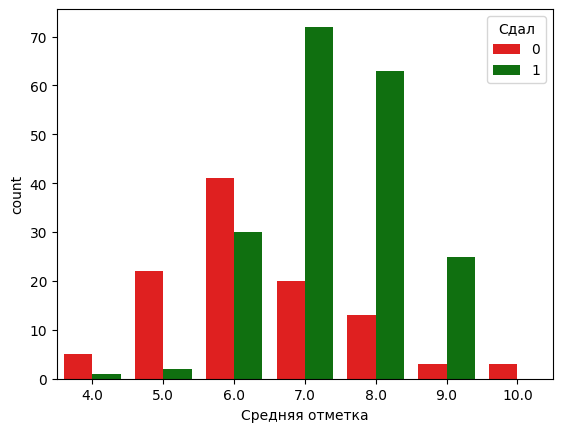

In [10]:
df = dataset[['Контрольная 1', 'Контрольная 2', 'Контрольная 3', 'Сдал']]
df['Средняя отметка'] = df.drop(['Сдал'], axis=1).mean(axis=1).round()
sns.countplot(x='Средняя отметка', hue='Сдал', data=df, palette=('red','green'))

In [11]:
# my_coeffs = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
my_coeffs = np.array([1,1,-1,1,1])
df['Мой рейтинг'] = dataset[
    ["Сон накануне","Настроение","Энергетиков накануне",
    "Посещаемость занятий","Время подготовки"]
    ].values @ my_coeffs
df

C:\Users\trxxnk\AppData\Local\Temp\ipykernel_11304\1461201663.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Мой рейтинг'] = dataset[


,Контрольная 1,Контрольная 2,Контрольная 3,Сдал,Средняя отметка,Мой рейтинг
0,4,4,9,0,6.0,1
1,9,9,6,1,8.0,1
2,8,6,9,1,8.0,1
3,8,4,9,1,7.0,5
4,9,10,4,1,8.0,0
...,...,...,...,...,...,...
295,9,10,6,0,8.0,-1
296,4,6,7,0,6.0,1
297,10,6,6,1,7.0,-1
298,6,4,5,0,5.0,5


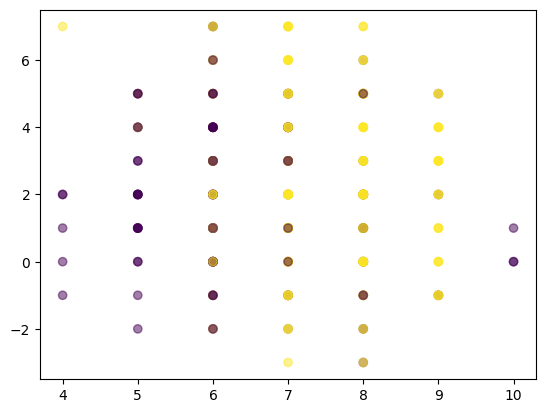

In [12]:
plt.scatter(x=df['Средняя отметка'], y=df['Мой рейтинг'], c=df['Сдал'], alpha=0.5)

In [13]:
X = dataset.drop(['Сдал'], axis=1).values
poly_features = PolynomialFeatures(degree=5)
X = poly_features.fit_transform(X)
y = dataset['Сдал'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test[:1], y_test[:1]

(array([[  1.,   4.,   6., ...,  27.,  81., 243.]]), array([1], dtype=int64))

In [14]:
model = LogisticRegression(max_iter=5_000)
model.fit(X_train, y_train)
model.score(X_train, y_train), model.score(X_test, y_test)

(1.0, 0.7833333333333333)

In [15]:
model = DecisionTreeClassifier(
    max_depth=10, 
    min_samples_split=3,
    min_samples_leaf=1)
model.fit(X_train, y_train)
model.score(X_train, y_train), model.score(X_test, y_test)

(0.9958333333333333, 0.95)

In [16]:
model = GaussianNB()
model.fit(X_train, y_train)
model.score(X_train, y_train), model.score(X_test, y_test)

(0.775, 0.6833333333333333)

In [17]:
tree = DecisionTreeClassifier()
scores = cross_val_score(tree, X, y, cv=7)
scores, np.mean(scores)

(array([0.93023256, 0.90697674, 0.97674419, 0.81395349, 0.93023256,
        0.95348837, 0.92857143]),
 0.9200284765068819)

In [18]:
param_grid = {
    'criterion': ['gini', 'entropy'], # Критерий разделения
    'max_depth': [5, 7, 10, 13], # Максимальная глубина дерева
    'min_samples_split': [2, 3, 5], # Минимальное количество образцов для разбиения
    'min_samples_leaf': [2, 5, 7], # Минимальное количество образцов в листе
    'max_features': [None, 'sqrt', 'log2'], # Максимальное количество признаков для рассмотрения при разбиении
}

tree = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

# Лучшие параметры и результат
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность (на обучающей выборке):", grid_search.best_score_)

# Оценка на тестовой выборке
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Точность на тестовой выборке:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Лучшие параметры: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Лучшая точность (на обучающей выборке): 0.9083333333333334
Точность на тестовой выборке: 0.9


d:\code-files\unik\ML\.ML-venv\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [19]:
tree = DecisionTreeClassifier(
    **grid_search.best_params_
)
scores = cross_val_score(tree, X, y, cv=5)
scores, np.mean(scores)

(array([0.93333333, 0.93333333, 0.95      , 0.91666667, 0.85      ]),
 0.9166666666666666)

In [20]:
class myDecisionTree():
    class Node:
        def __init__(self, threshold:float, feature:int, left_node:Literal["Node"]=None, right_node:Literal["Node"]=None):
            self.threshold = threshold
            self.feature = feature
            self.left_node = left_node
            self.right_node = right_node
            self.value = None
            self._depth = None 
            
        def __repr__(self) -> str:
            left_data_str = f" left_thr = {self.left_node.threshold}, left_ft = {self.left_node.feature}\n" if self.left_node else "-"
            right_data_str = f" right_thr = {self.right_node.threshold}, right_ft = {self.right_node.feature}" if self.right_node else "-"
            return f"{self.threshold=},\n{self.feature=},\n{self.value=},\n" + left_data_str + right_data_str
                
        def __str__(self) -> str:
            return self.__repr__()
    
    def __init__(self, decision:Literal['gini', 'entropy'] = 'entropy',
                 max_depth:int=10, min_samples_split:int=3):
        self._root = None
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.decision = decision
        
    def fit(self, X_train:np.ndarray, y_train:np.ndarray) -> None:
        feature, threshold = self._best_split(X_train, y_train)
        self._root = self.Node(threshold, feature)
        self._root._depth = 1
        queue = [(self._root, X_train, y_train)]
        while queue:
            node, X, y = queue.pop(0)
            new_depth = node._depth + 1
            feature, threshold = node.feature, node.threshold
            X_left, X_right, y_left, y_right = self._left_rigth_split(X, y, feature, threshold)
            
            left_feature, left_threshold = self._best_split(X_left, y_left)
            left_node = self.Node(left_threshold, left_feature)
            left_node._depth = new_depth
            if y_left.size > self.min_samples_split and new_depth < self.max_depth:
                queue.append((left_node, X_left, y_left))
            else:
                left_node.value = mode(y_left)[0]
            
            right_feature, right_threshold = self._best_split(X_right, y_right)
            right_node = self.Node(right_threshold, right_feature)
            right_node._depth = new_depth
            if y_right.size > self.min_samples_split and new_depth <= self.max_depth:
                queue.append((right_node, X_right, y_right))
            else:
                right_node.value = mode(y_right)[0]
            
            node.left_node = left_node
            node.right_node = right_node
            
        return None
    
    def predict(self, X:np.ndarray) -> np.ndarray:
        y_pred = []
        for x0 in X:
            cur_node = self._root
            while cur_node.value is None:
                cur_feature = cur_node.feature
                cur_threshold = cur_node.threshold
                if x0[cur_feature] <= cur_threshold:
                    cur_node = cur_node.left_node
                else:
                    cur_node = cur_node.right_node
            y_pred.append(cur_node.value)
        return np.array(y_pred, dtype='int32')
    
    def score(self, X_test:np.ndarray, y_test:np.ndarray) -> float:
        y_pred = self.predict(X_test)
        n_true = np.sum((y_pred == y_test))
        n_all = y_test.shape[0]
        return n_true / n_all
    
    def _left_rigth_split(self, X:np.ndarray, y:np.ndarray, feature:int, threshold:float) -> tuple[np.ndarray]:
        left_indexes, right_indexes = self._split(X[:, feature], threshold)
        return X[left_indexes], X[right_indexes], y[left_indexes], y[right_indexes]
            
    def _split(self, X:np.ndarray, threshold:float) -> tuple[np.ndarray, np.ndarray]:
        left_indexes = (X <= threshold)
        right_indexes = (X > threshold)
        return left_indexes, right_indexes
    
    def _best_split(self, X:np.ndarray, y:np.ndarray) -> tuple[int, float]:
        n_features = X.shape[1]
        max_gain = -np.inf
        best_feature, best_threshold = None, None
        decision_function = self._get_decision_function(self.decision)
        entropy = decision_function(y)
        
        for idx_cur_feature in range(n_features):
            unique_feature_values = np.unique(X[:,idx_cur_feature])
            for i in range(1, len(unique_feature_values)):
                current_value = unique_feature_values[i]
                previous_value = unique_feature_values[i-1]
                threshold = (current_value + previous_value) / 2
                
                left_indexes, right_indexes = self._split(X[:,idx_cur_feature], threshold)
                
                left_cost = decision_function(y[left_indexes]) 
                right_cost = decision_function(y[right_indexes])
                cur_gain = entropy - (left_cost * np.sum(left_indexes) / y.size + right_cost * np.sum(right_indexes) / y.size)
                if cur_gain > max_gain:
                    max_gain = cur_gain
                    best_feature = idx_cur_feature
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    def _get_decision_function(self, decision:str) -> Literal['Function']:
        _decision_functions = {'gini':self._gini, 'entropy':self._entropy}
        return _decision_functions[decision]
    
    @staticmethod
    def _entropy(arr:np.ndarray, base:int=2) -> float:
        n = arr.size
        _, counts = np.unique(arr, return_counts=True)
        p = counts / n
        _log_base = lambda val, base: np.log(val) / np.log(base)
        _log = lambda val: _log_base(val, base) if _log_base(val, base)[0] != np.inf else 0
        log_p = np.apply_along_axis(_log, 0, p)
        entropy = - p @ log_p
        return entropy
    
    @staticmethod
    def _gini(arr:np.ndarray) -> float:
        n = arr.size
        _, counts = np.unique(arr, return_counts=True)
        p = counts / n
        gini = 1 - np.sum(p ** 2)
        return gini

In [21]:
tX, ty = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_classes=2)
tX_train, tX_test, ty_train, ty_test = train_test_split(tX, ty, test_size=0.2, random_state=42)
tX_test[:5], ty_test[:5]

(array([[ 0.70970288, -1.49751722],
        [-0.12855694, -2.09834443],
        [-1.02855377,  1.42677069],
        [ 0.01252609, -1.71746843],
        [ 0.75612762, -1.54894645]]),
 array([0, 1, 1, 0, 0]))

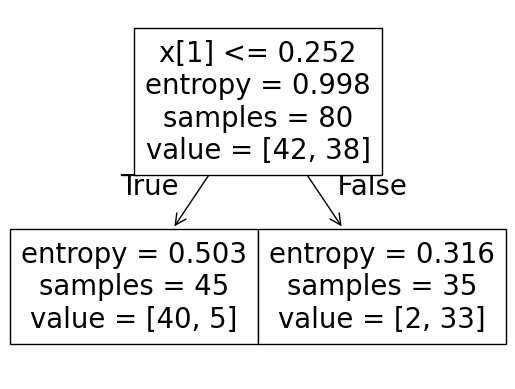

In [22]:
sk_tree = DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=1, min_samples_split=5)
sk_tree.fit(tX_train, ty_train)
sk_tree.score(tX_test, ty_test)
plot_tree(sk_tree);

In [23]:
my_tree = myDecisionTree(decision='entropy', max_depth=1, min_samples_split=5)
my_tree.fit(tX_train, ty_train)
my_tree.score(tX_test, ty_test)

0.8

In [24]:
my_tree._root

self.threshold=0.25197553941533624,
self.feature=1,
self.value=None,
 left_thr = -0.31124812169022775, left_ft = 1
 right_thr = 1.61393229606375, right_ft = 0